In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.feature_selection import mutual_info_classif
from sklearn.preprocessing import LabelEncoder

DATA_PATH = Path("../data/processed/bank_fraud_poc_sample.csv")

df = pd.read_csv(DATA_PATH)

df.head()

,transaction_id,customer_id,transaction_date,transaction_time,hour_of_day,is_weekend,is_night_transaction,country,city,merchant_category,...,transaction_amount,num_prev_transactions,transaction_freq_monthly,distance_from_home_km,time_since_last_txn_hrs,is_international,failed_attempts,pin_changed_recently,is_fraud,fraud_type
0,TXN0000000001,CUST00121959,2023-08-17,21:13:00,21,0,0,USA,London,Grocery,...,39.49,157,23,52.7,10.20,0,0,0,0,NaN
1,TXN0000000010,CUST00087499,2020-03-30,21:08:00,21,0,0,Mexico,Mumbai,Crypto Exchange,...,139.81,154,29,1.2,16.54,0,0,0,0,NaN
2,TXN0000000017,CUST00067222,2023-08-28,03:03:00,3,0,1,USA,London,Fuel,...,169.83,145,22,32.0,6.46,0,0,0,0,NaN
3,TXN0000000021,CUST00194028,2021-01-23,06:03:00,6,1,1,USA,Manchester,Online Shopping,...,31.09,127,16,2.2,4.88,0,0,0,0,NaN
4,TXN0000000028,CUST00159766,2021-06-09,02:31:00,2,0,1,Japan,São Paulo,Crypto Exchange,...,26.33,136,26,0.9,1.23,1,5,0,1,Synthetic Identity


In [2]:
print("Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

print("\nData types:")
print(df.dtypes)

print("\nMissing values:")
print(df.isnull().sum())

print("\nDuplicates:")
print(df.duplicated().sum())

Shape: (100000, 26)

Columns:
['transaction_id', 'customer_id', 'transaction_date', 'transaction_time', 'hour_of_day', 'is_weekend', 'is_night_transaction', 'country', 'city', 'merchant_category', 'payment_method', 'device_type', 'customer_age', 'credit_score', 'account_age_years', 'account_balance', 'transaction_amount', 'num_prev_transactions', 'transaction_freq_monthly', 'distance_from_home_km', 'time_since_last_txn_hrs', 'is_international', 'failed_attempts', 'pin_changed_recently', 'is_fraud', 'fraud_type']

Data types:
transaction_id                  str
customer_id                     str
transaction_date                str
transaction_time                str
hour_of_day                   int64
is_weekend                    int64
is_night_transaction          int64
country                         str
city                            str
merchant_category               str
payment_method                  str
device_type                     str
customer_age                  int64
c

In [3]:
target_counts = df["is_fraud"].value_counts()
target_percent = df["is_fraud"].value_counts(normalize=True) * 100

print(target_counts)
print()
print(target_percent)

is_fraud
0    94474
1     5526
Name: count, dtype: int64

is_fraud
0    94.474
1     5.526
Name: proportion, dtype: float64


In [4]:
categorical_columns = [
    "country",
    "city",
    "merchant_category",
    "payment_method",
    "device_type",
]

for column in categorical_columns:
    summary = (
        df.groupby(column)["is_fraud"]
        .agg(["count", "sum", "mean"])
        .rename(
            columns={
                "count": "transaction_count",
                "sum": "fraud_count",
                "mean": "fraud_rate",
            }
        )
        .sort_values("fraud_rate", ascending=False)
    )

    summary["fraud_rate"] *= 100

    print(f"\n{column}")
    print(summary)


country
           transaction_count  fraud_count  fraud_rate
country                                              
Mexico                  6028          344    5.706702
USA                    30010         1707    5.688104
India                  11955          667    5.579256
France                  6993          386    5.519806
Canada                  7026          385    5.479647
Germany                 8059          439    5.447326
Brazil                  8028          436    5.430992
UK                      9942          539    5.421444
Australia               5071          266    5.245514
Japan                   6888          357    5.182927

city
             transaction_count  fraud_count  fraud_rate
city                                                   
Vancouver                 4954          294    5.934598
Los Angeles               4993          295    5.908272
Toronto                   5068          299    5.899763
Mexico City               5020          292    5.816733
M

In [5]:
risk_columns = [
    "is_night_transaction",
    "is_international",
    "failed_attempts",
    "pin_changed_recently",
]

for column in risk_columns:
    summary = (
        df.groupby(column)["is_fraud"]
        .agg(["count", "sum", "mean"])
        .rename(
            columns={
                "count": "transaction_count",
                "sum": "fraud_count",
                "mean": "fraud_rate",
            }
        )
    )

    summary["fraud_rate"] *= 100

    print(f"\n{column}")
    print(summary)


is_night_transaction
                      transaction_count  fraud_count  fraud_rate
is_night_transaction                                            
0                                 62443         2555    4.091732
1                                 37557         2971    7.910642

is_international
                  transaction_count  fraud_count  fraud_rate
is_international                                            
0                             84983         4041    4.755069
1                             15017         1485    9.888793

failed_attempts
                 transaction_count  fraud_count  fraud_rate
failed_attempts                                            
0                            80022         3568    4.458774
1                             9925          486    4.896725
2                             5135          782   15.228822
3                             2980          413   13.859060
4                              990          127   12.828283
5                  

In [6]:
numerical_columns = [
    "customer_age",
    "credit_score",
    "account_age_years",
    "account_balance",
    "transaction_amount",
    "num_prev_transactions",
    "transaction_freq_monthly",
    "distance_from_home_km",
    "time_since_last_txn_hrs",
    "failed_attempts",
]

for column in numerical_columns:
    summary = (
        df.groupby("is_fraud")[column]
        .agg(["mean", "median", "std"])
    )

    print(f"\n{column}")
    print(summary)


customer_age
               mean  median        std
is_fraud                              
0         41.777516    41.0  13.446424
1         41.441911    41.0  13.243592

credit_score
                mean  median        std
is_fraud                               
0         679.416633   680.0  78.364708
1         678.291350   678.0  81.145115

account_age_years
              mean  median       std
is_fraud                            
0         5.003235     3.5  4.946314
1         5.013952     3.6  4.810569

account_balance
                  mean    median           std
is_fraud                                      
0         16444.037586  8025.235  27820.255228
1         16525.157828  8030.255  28841.072012

transaction_amount
                mean  median         std
is_fraud                                
0         200.238581  72.730  435.451608
1         234.298281  77.675  531.783697

num_prev_transactions
                mean  median        std
is_fraud                             

In [7]:
numeric_df = df.select_dtypes(include=np.number)

correlations = (
    numeric_df.corr()["is_fraud"]
    .drop("is_fraud")
    .sort_values(key=abs, ascending=False)
)

print(correlations)

failed_attempts             0.118346
is_night_transaction        0.080940
is_international            0.080265
pin_changed_recently        0.039426
hour_of_day                -0.035845
transaction_amount          0.017631
time_since_last_txn_hrs    -0.007261
customer_age               -0.005707
is_weekend                  0.003541
credit_score               -0.003274
distance_from_home_km       0.003104
transaction_freq_monthly    0.002480
account_balance             0.000665
account_age_years           0.000496
num_prev_transactions      -0.000196
Name: is_fraud, dtype: float64


In [8]:
numeric_df = df.select_dtypes(include=np.number)

correlations = (
    numeric_df.corr()["is_fraud"]
    .drop("is_fraud")
    .sort_values(key=abs, ascending=False)
)

print(correlations)

failed_attempts             0.118346
is_night_transaction        0.080940
is_international            0.080265
pin_changed_recently        0.039426
hour_of_day                -0.035845
transaction_amount          0.017631
time_since_last_txn_hrs    -0.007261
customer_age               -0.005707
is_weekend                  0.003541
credit_score               -0.003274
distance_from_home_km       0.003104
transaction_freq_monthly    0.002480
account_balance             0.000665
account_age_years           0.000496
num_prev_transactions      -0.000196
Name: is_fraud, dtype: float64


In [9]:
excluded_columns = [
    "transaction_id",
    "customer_id",
    "transaction_date",
    "transaction_time",
    "fraud_type",
    "is_fraud",
]

features = df.drop(columns=excluded_columns).copy()

categorical_features = features.select_dtypes(
    include=["object", "string", "category"]
).columns

for column in categorical_features:
    encoder = LabelEncoder()
    features[column] = encoder.fit_transform(
        features[column].astype(str)
    )

X = features
y = df["is_fraud"]

mi_scores = mutual_info_classif(
    X,
    y,
    random_state=42,
)

mi_results = (
    pd.DataFrame(
        {
            "feature": X.columns,
            "mutual_information": mi_scores,
        }
    )
    .sort_values(
        "mutual_information",
        ascending=False,
    )
)

mi_results

,feature,mutual_information
2,is_night_transaction,0.011669
18,failed_attempts,0.005945
6,payment_method,0.005668
7,device_type,0.004831
1,is_weekend,0.004383
17,is_international,0.004159
3,country,0.004125
0,hour_of_day,0.004037
5,merchant_category,0.003904
14,transaction_freq_monthly,0.001458


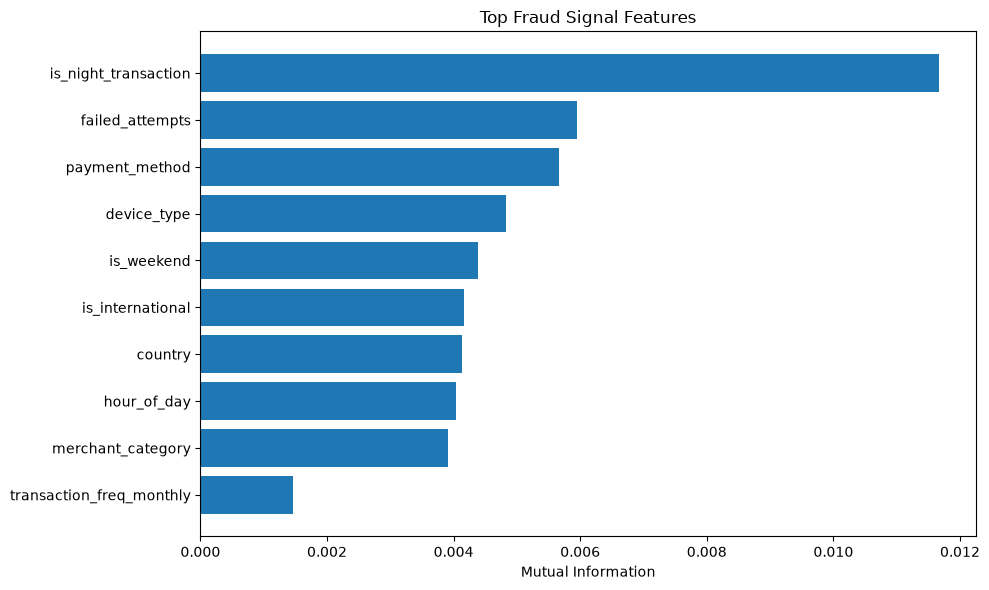

In [10]:
top_features = mi_results.head(10)

plt.figure(figsize=(10, 6))
plt.barh(
    top_features["feature"][::-1],
    top_features["mutual_information"][::-1],
)
plt.xlabel("Mutual Information")
plt.title("Top Fraud Signal Features")
plt.tight_layout()
plt.show()